# <center> TP2 : Algorithmique de l'Image </center>

## <center>  Transformées de Fourier </center>

***
# Plan : 
*** 
## I. Retour sur les Contours Actifs (Levels Sets)

## II. Transformée de Fourier
    1. Transformée de Fourier Discrète
    2. Transformée de Fourier Discrète Inverse
    


In [1]:
import os
import sys
import cv2 as cv2
import matplotlib.cm as cm
from scipy.ndimage import filters
import numpy as np
import pylab as plb
import matplotlib.pyplot as plt
import copy
import scipy.ndimage
import scipy.ndimage as nd

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2


%matplotlib inline



## I. Contours Actifs (Levels Sets)
---

Les contours actifs basés sur les ensembles de niveaux permettent de détecter des contours dans une image en modélisant leur évolution sous forme d'une équation aux dérivées partielles (EDP). Cette méthode est particulièrement utile pour les images avec des bordures complexes.

### Segmentation d'Image avec Level Sets et la fonction d'Héaviside

#### Gestion des fonctions d'ensemble de niveaux 
---
Dans le formalisme des ensembles de niveaux, l'évolution d'une courbe : $ (\gamma(t))_{t=0}^1 $  

est calculée en faisant évoluer le niveau zéro d'une fonction 

$$ 
\phi : \mathbb{R}^2 \rightarrow \mathbb{R} 
$$  
$$ \gamma(s) = \{ x \in \mathbb{R}^2 \mid \phi(x) = 0 \}, \quad \text{pour} \quad s \in [0,1]. $$

Cela correspond à remplacer la représentation paramétrique $ \gamma $ de la courbe par une représentation implicite.  
Ce choix nécessite une dimension supplémentaire (et donc plus de stockage), mais il simplifie la gestion des changements topologiques de la courbe au cours de son évolution.

---

#### Discrétisation

La taille de la discrétisation est $n \times n$ pour le domaine $[0,1]^2$.

<!--
#### Fonction d'Héaviside

La **fonction d'Héaviside** est utilisée pour distinguer les régions à l'intérieur et à l'extérieur d'un contour, souvent dans les algorithmes de **Level Sets** pour la segmentation d'images.

Elle est généralement utilisée pour identifier et activer les régions à l'intérieur du contour (contour actif) et à l'extérieur du contour. La fonction prend la valeur suivante :

- $ H(\varphi(x)) = 0 $ lorsque $ \varphi(x) $ est à l'intérieur du contour (zone négative),
- $ H(\varphi(x)) = 1 $ lorsque $ \varphi(x) $ est à l'extérieur du contour (zone positive).

##### Définition de la fonction d'Héaviside

Mathématiquement, la fonction d'Héaviside $ H(\varphi(x)) $ peut être définie comme suit :

$
H(\varphi(x)) = \frac{1}{2} \left( 1 + \frac{2}{\pi} \arctan\left(\frac{\varphi(x)}{\epsilon}\right) \right)
$

où :
- $ \varphi(x) $ est la fonction de niveau (souvent appelée le champ de niveau), qui représente la distance par rapport au contour à chaque point de l'image.
- $ \epsilon $ est un petit paramètre qui contrôle la largeur de la transition entre les régions intérieure et extérieure (généralement très petit, par exemple $ \epsilon = 1 $).

### Rôle de la fonction d'Héaviside dans les Level Sets

La fonction d'Héaviside joue un rôle clé dans l'algorithme des **Level Sets** en définissant la frontière dynamique entre les différentes régions :

- À l'intérieur du contour, la fonction $ H(\varphi) $ est proche de 0.
- À l'extérieur du contour, la fonction $ H(\varphi) $ est proche de 1.

Cela permet de définir de manière implicite les régions de l'image qui sont "à l'intérieur" ou "à l'extérieur" du contour évolutif. Cette distinction est essentielle pour l'évolution du contour actif et la segmentation des objets dans l'image.

### Visualisation de la fonction d'Héaviside

La fonction d'Héaviside peut être visualisée comme une transition douce entre les valeurs 0 et 1 autour du contour, ce qui permet à l'algorithme des Level Sets de fonctionner de manière fluide et stable au fil de son évolution. -->


In [2]:
n = 200
Y,X = np.meshgrid(np.arange(1,n+1), np.arange(1,n+1))

On peut créer une forme circulaire en utilisant la fonction de distance signée à un cercle :  
$$ 
\phi_1(x) = \sqrt{ (x_1 - c_1)^2 + (x_2 - c_2)^2 } - r 
$$  
où $ r > 0 $ est le rayon et $ c \in \mathbb{R}^2 $ représente le centre.

---

## Rayon $ r $

In [3]:
r = n/3.

Centre $c$ :  

In [4]:
c = np.array([r,r]) + 10

Fonction de distance $\phi_1$ :

In [6]:
# code à compléter ...
# courbe de niveaux
phi1 = np.sqrt((X - c[0])**2 + (Y - c[1])**2) - r

__Exercice 1__

Chargez une forme carrée $\phi_2$ à une position différente pour le centre.

---

##### Fonction de distance pour un carré $\phi_2$

Pour créer une forme carrée en utilisant une fonction de distance signée, la fonction de distance pour un carré avec un centre déplacé serait donnée par :

$$ \phi_2(x) = \max \left( |x_1 - c_1|, |x_2 - c_2| \right) - a $$

où :
- $c = (c_1, c_2)$ est le centre du carré,
- $a$ est la demi-longueur du côté du carré.


In [7]:
## A Compléter ... 
# ... 
c = n - 10  - np.array([r,r])
phi2 = np.maximum(np.abs(X - c[0]), np.abs(Y - c[1])) - r 


Affichez les courbes associées à $\phi_1$ et $\phi_2$.

---

##### Courbes associées à $\phi_1$ et $\phi_2$

- La courbe associée à $\phi_1$ correspond à un cercle de rayon $r$ centré en $c = (c_1, c_2)$.
- La courbe associée à $\phi_2$ correspond à un carré de demi-longueur de côté $a$ centré en $c = (c_1, c_2)$.



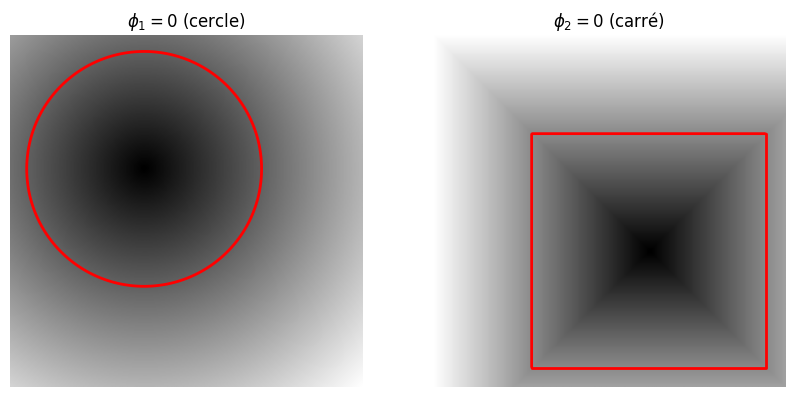

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_levelset(Z, level=0, f=None, title="", cmap="gray",
                  contour_color="red", contour_lw=2):
    """
    Affiche une image (f) et superpose le contour Z=level.

    Paramètres
    ----------
    Z : ndarray (H,W)
        Fonction de niveau (phi).
    level : float
        Niveau à tracer (souvent 0).
    f : ndarray (H,W) ou None
        Image de fond. Si None, affiche Z.
    title : str
        Titre du subplot.
    cmap : str
        Colormap pour l'image de fond.
    contour_color : str
        Couleur du contour.
    contour_lw : float
        Epaisseur du contour.
    """

    # A Compléter ...
    # ...
    plt.imshow(f if f is not None else Z, cmap=cmap, origin='upper')
    plt.contour(Z, levels=[level], colors=contour_color, linewidths=contour_lw)
    plt.title(title)
    plt.axis('off')


# =========================
# Exemple : phi1 (cercle) et phi2 (carré)
# =========================


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plot_levelset(phi1, level=0, f=None, title=r"$\phi_1=0$ (cercle)")

plt.subplot(1, 2, 2)
plot_levelset(phi2 , level=0, f=None, title=r"$\phi_2=0$ (carré)")





plt.show()



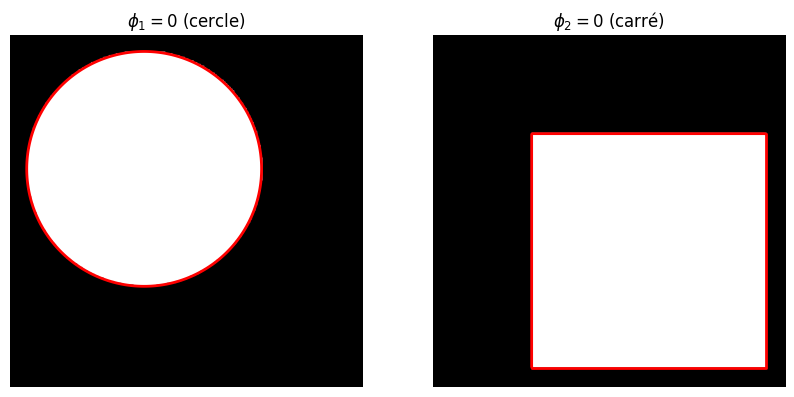

In [9]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)


f = (phi1 < 0)
plot_levelset(phi1, f=f, title=r"$\phi_1=0$ (cercle)")

plt.subplot(1, 2, 2)


f = (phi2 < 0) # pour reperer ce qu'il y a a l'interieur

plot_levelset(phi2, f=f, title=r"$\phi_2=0$ (carré)")


plt.show()

__Exercice 2__

Calculez l'intersection et l'union des deux formes.  
Stockez l'union dans $\phi_0$ (phi0) que nous utiliserons dans la suite du tutoriel.

---

##### Intersection et Union des Formes

L'intersection de deux formes correspond aux points où les deux fonctions de niveau sont positives (ou zéro), tandis que l'union correspond aux points où l'une des deux fonctions de niveau est positive (ou zéro).

- **Intersection** : $\phi_{\text{intersection}}(x) = \min(\phi_1(x), \phi_2(x))$
- **Union** : $\phi_{\text{union}}(x) = \max(\phi_1(x), \phi_2(x))$

Nous allons stocker l'union dans $\phi_0$ pour l'utiliser dans la suite des exercices.


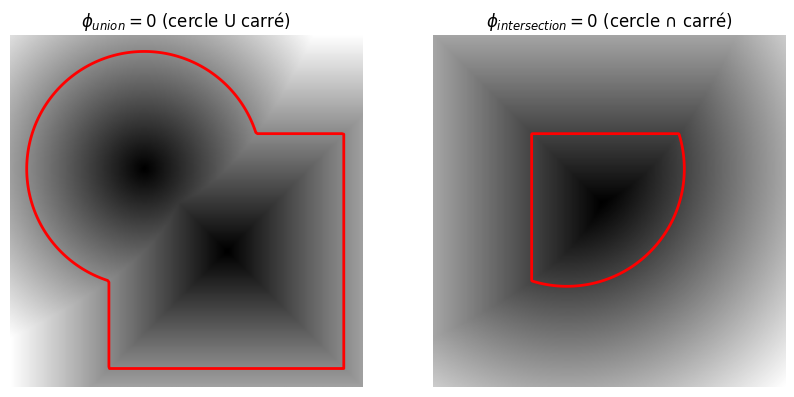

In [10]:
# Intersection et union (logique des fonctions de niveau)
# A compléter ...
# ...
intersection = np.maximum(phi1, phi2)  
union = np.minimum(phi1, phi2)  
plt.figure(figsize=(10, 5))
# ...
# ...
# ...
plt.subplot(1, 2, 1)
plot_levelset(union, level=0, title=r"$\phi_{union}=0$ (cercle U carré)")
plt.subplot(1, 2, 2)
plot_levelset(intersection, level=0, title=r"$\phi_{intersection}=0$ (cercle ∩ carré)")

plt.show()


<!--
##### Re-distanciation du Levelset

Lors de la résolution des équations aux dérivées partielles (EDP), une fonction de level set $\phi$ peut devenir mal conditionnée, de sorte que le passage par zéro n'est pas assez net. La qualité de la fonction de level set est restaurée en calculant la fonction de distance signée jusqu'au niveau zéro.

Cela correspond d'abord à l'extraction du niveau zéro :
$$ \mathcal{C} = \left\{ x \in \mathbb{R}^2 \mid \phi(x) = 0 \right\}, $$

Puis à la résolution de l'équation de type eikonal suivante pour $\tilde{\phi}$ (dans le sens de la viscosité) :
$$ \left\| \nabla \tilde{\phi}(x) \right\| = 1 \quad \text{et} \quad \forall y \in \mathcal{C}, \tilde{\phi}(y) = 0. $$

On peut ensuite remplacer $\phi$ par $\text{sign}(\phi(x)) \tilde{\phi}(x)$, qui est la fonction de distance signée à $\mathcal{C}$.

Nous définissons $\phi = \phi_0^3$, de sorte qu'elles soient toutes deux des fonctions de level set valides pour la même courbe, mais $\phi$ n'est pas la fonction de distance signée.
-->

# Segmentation basée sur les régions avec Chan-Vese

La méthode des contours actifs de **Chan-Vese** correspond à une énergie basée sur les régions qui cherche une approximation par morceaux constants de l'image.

### L'énergie à minimiser

L'énergie à minimiser est donnée par :

$$
\min_{\phi} \, 
L(\phi) + 
\lambda \int_{\phi(x)>0} \left| f_0(x) - c_1 \right|^2 \, dx + 
\lambda \int_{\phi(x)<0} \left| f_0(x) - c_2 \right|^2 \, dx
$$

où $ L(\phi) $ représente la longueur de l'ensemble de niveau zéro de $ \phi $, et $ f_0(x) $ est l'intensité de l'image en chaque point $ x $.

### Paramètres

- **$ L(\phi) $** : La longueur du contour actif, qui dépend de l'évolution de la fonction $ \phi $.
- **$ \lambda $** : Un paramètre de régularisation qui contrôle l'importance de l'énergie de régularisation par rapport à l'énergie de données.
- **$ c_1 $ et $ c_2 $** : Les valeurs moyennes des intensités dans les régions où $ \phi(x) > 0 $ et $ \phi(x) < 0 $, respectivement. Ces valeurs sont généralement supposées être connues dans le cadre de la segmentation.

### Objectif

L'objectif de la méthode est de trouver un contour $ \phi $ qui sépare l'image en deux régions. La fonction $ \phi(x) $ prend la valeur **positive** pour la première région (par exemple, l'objet à segmenter), et la valeur **négative** pour la deuxième région (par exemple, l'arrière-plan). Le terme de longueur $ L(\phi) $ pénalise la complexité du contour, tandis que les termes de données cherchent à faire en sorte que les moyennes d'intensité dans chaque région soient proches des valeurs $ c_1 $ et $ c_2 $.



In [11]:
from skimage import io,color
from skimage.transform import resize
from skimage.transform import rescale


img=io.imread("images/cortex.bmp")
img = color.rgb2gray(img)
# Convert to grayscale

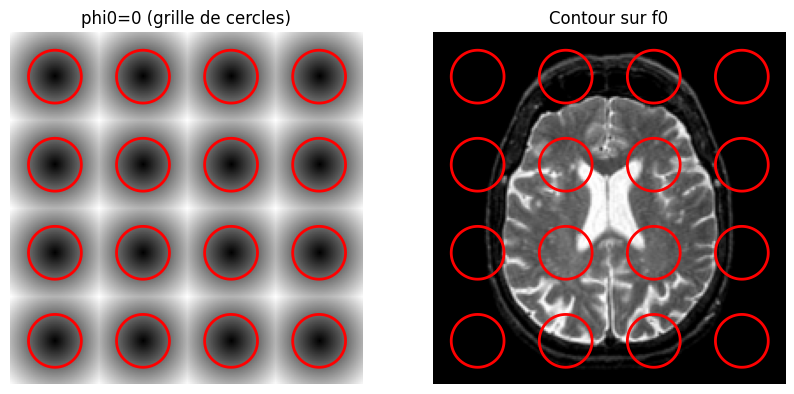

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from skimage.transform import resize

f0 = resize(img, (n, n), anti_aliasing=True)

Y, X = np.mgrid[0:n, 0:n]   # indices image: 0..n-1

k = 4
r = 0.3 * n / k

# ....
# ....


phi0 = np.full((n, n), np.inf)

for i in range(0,k+1):
    for j in range(0,k+1):
        c = np.array([(i + 0.5) * n / k, (j + 0.5) * n / k])
        cercle = np.sqrt((X - c[0])**2 + (Y - c[1])**2) - r
        phi0 = np.minimum(phi0, cercle)
        

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plot_levelset(phi0, 0, title="phi0=0 (grille de cercles)")

plt.subplot(1,2,2)
plot_levelset(phi0, 0, f0, title="Contour sur f0")
plt.show()


Paramètre $\lambda$

In [13]:
lambd = 2

Valeurs pour $c_1,c_2$

In [14]:
c1 = .7
c2 = 0

pas de gradient"

In [15]:
tau = .5

Nombre d'itérations.

In [16]:
Tmax = 100
niter = int(Tmax/ tau)

Fonction de distance initiale $\phi_0$ au temps $t=0$.

In [17]:
phi = np.copy(phi0)

# Le flux minimisant pour l'énergie CV

Le flux minimisant pour l'énergie de Chan-Vese est donné par l'équation suivante :

$$
\frac{\partial \phi_t}{\partial t} = - G(\phi_t)
$$

où $ G(\phi) $ est défini par :

$$
G(\phi) = 
- W \|\nabla \phi\| \, \text{div}\left( 
	\frac{\nabla \phi}{\|\nabla \phi\|}
\right) + \lambda \left( (f_0 - c_1)^2 \right) - \lambda \left( (f_0 - c_2)^2 \right)
$$

### Explications :

- $ \frac{\partial \phi_t}{\partial t} $ représente l'évolution de la fonction $ \phi $ au fil du temps.
- $ G(\phi) $ comprend deux parties :
  - Le premier terme $ - W \|\nabla \phi\| \, \text{div}\left( \frac{\nabla \phi}{\|\nabla \phi\|} \right) $ est lié à la régularisation de la longueur du contour actif (énergie géodésique).
  - Les deux derniers termes $ \lambda \left( (f_0 - c_1)^2 \right) $ et $ - \lambda \left( (f_0 - c_2)^2 \right) $ sont des termes de données qui minimisent la différence entre les intensités de l'image $ f_0 $ et les moyennes $ c_1 $ et $ c_2 $ des régions respectivement à l'intérieur et à l'extérieur du contour actif.


__Exercise 8__

Compute this gradient $G(\phi)$ using the current value of the distance function
(phi$.
radient

In [18]:

G =  + lambd * ( (f0 - c1)**2 - (f0 - c2)**2 ) - (np.gradient(phi))

Effectuer un pas de descente.

In [19]:
# A compléter ...
phi = phi + tau * G

__Exercice 9__

Implémentez la descente de gradient complète.

In [ ]:
from scipy.ndimage import distance_transform_edt

def perform_redistancing(phi):
    """
    Recalcule une distance signée à partir du signe de phi.
    Convention : phi<0 intérieur, phi>0 extérieur.
    """
    inside = phi < 0
    outside = phi > 0

    dist_out = distance_transform_edt(outside)
    dist_in = distance_transform_edt(inside)

    phi_new = dist_out - dist_in
    return phi_new


plt.figure(figsize=(10,10))
phi = np.copy(phi0)
k = 0

for i in range(1, niter+1):

    phi_x = np.gradient(phi, axis=1)
    phi_y = np.gradient(phi, axis=0)

    grad_norm = np.sqrt(phi_x**2 + phi_y**2 + 1e-10)

    G = f0   

    phi = phi - tau * G * grad_norm

    if i % 30 == 0:
        phi = perform_redistancing(phi)

    if i % int(niter/4.) == 0:
        k = k + 1
        plt.subplot(2, 2, k)
        plot_levelset(phi, 0, f0)

plt.show()

*** 
## I. Transformée de Fourier Discrète
*** 

### A) Transformée de Fourier Discrète (TDF)

La **Transformée de Fourier Discrète (TDF)** est un outil mathématique qui permet de décomposer un signal ou une image en une somme de sinusoïdes de fréquences discrètes. Elle est largement utilisée dans le traitement du signal et de l'image, notamment pour l'analyse des fréquences, la compression d'images et la reconstruction de signaux.

#### 1. Définition de la TDF

La TDF d'un signal discret \( f(n) \) de taille \( N \) est définie par la formule :

$$ F(k) = \sum_{n=0}^{N-1} f(n) e^{-2\pi i \frac{k n}{N}} \quad \text{pour} \quad k = 0, 1, \dots, N-1 $$

Où :
- \( f(n) \) est le signal discret dans le domaine temporel ou spatial.
- \( F(k) \) est le signal transformé dans le domaine fréquentiel.
- \( e^{-2\pi i \frac{k n}{N}} \) est le noyau complexe de la transformée de Fourier.

#### 2. Transformée de Fourier Discrète 2D (TDFI)

La **Transformée de Fourier Discrète 2D (TDFI)** est une extension de la TDF aux images, permettant de décomposer une image en fréquences. Pour une image \( I(x, y) \) de dimensions \( M \times N \), la TDFI est définie comme :

$$ F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} I(x, y) e^{-2\pi i \left( \frac{u x}{M} + \frac{v y}{N} \right)} $$

Où :
- \( I(x, y) \) est l'intensité de l'image en la position \( (x, y) \).
- \( F(u, v) \) est la représentation de l'image dans le domaine fréquentiel.

#### Propriétés de la TDF

- **Linéarité** : La TDF est linéaire, c'est-à-dire que la TDF d'une somme de signaux est égale à la somme des TDF des signaux.
  
- **Symétrie** : La TDF de signaux réels est symétrique, ce qui implique que les fréquences négatives peuvent être obtenues à partir des fréquences positives.

- **Périodicité** : La TDF est périodique, ce qui signifie que les résultats de la transformée peuvent être répétés dans le domaine fréquentiel.

#### Applications de la TDF

La TDF est utilisée dans de nombreuses applications, telles que :
- La **compression d'images** (par exemple JPEG) en séparant les composantes fréquencielles.
- L'**analyse des fréquences** dans les signaux audio et vidéo.
- Le **filtrage d'images**, comme dans le cas de la suppression de bruit ou du lissage.
- Le **traitement du signal** pour extraire des informations de fréquence.

### B). Transformée de Fourier Discrète Inverse (TDFI)

La **Transformée de Fourier Discrète Inverse (TDFI)** permet de reconstruire un signal ou une image dans le domaine temporel ou spatial à partir de sa représentation fréquentielle obtenue par la TDF. En d'autres termes, elle est utilisée pour passer du domaine fréquentiel au domaine original.

#### 1. Définition de la TDFI

La **TDFI** d'un signal \( F(k) \) de taille \( N \) est définie par la formule suivante :

$$ f(n) = \frac{1}{N} \sum_{k=0}^{N-1} F(k) e^{2\pi i \frac{k n}{N}} \quad \text{pour} \quad n = 0, 1, \dots, N-1 $$

Où :
- \( F(k) \) est le signal transformé dans le domaine fréquentiel.
- \( f(n) \) est le signal reconstruit dans le domaine temporel ou spatial.
- \( e^{2\pi i \frac{k n}{N}} \) est le noyau complexe de la TDFI.

#### 2. Transformée de Fourier Discrète Inverse 2D (TDFI 2D)

La **TDFI 2D** est l'inverse de la **TDFI** pour les images. Si \( F(u, v) \) est la représentation fréquentielle d'une image \( I(x, y) \), la reconstruction de l'image dans le domaine spatial se fait comme suit :

$$ I(x, y) = \frac{1}{M N} \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} F(u, v) e^{2\pi i \left( \frac{u x}{M} + \frac{v y}{N} \right)} $$

Où :
- \( F(u, v) \) est l'image dans le domaine fréquentiel.
- \( I(x, y) \) est l'image reconstruite dans le domaine spatial.

#### Propriétés de la TDFI

- **Linéarité** : La TDFI est linéaire, comme la TDF. La TDFI d'une somme de signaux est égale à la somme des TDFIs des signaux.
  
- **Symétrie** : La TDFI d'une signal symétrique dans le domaine fréquentiel aboutira à un signal symétrique dans le domaine spatial.

- **Périodicité** : La TDFI est périodique, et donc le signal reconstruit peut être périodique également.

#### Applications de la TDFI

La TDFI est utilisée dans de nombreuses applications, notamment :
- **Reconstruction d'images** : Après avoir filtré ou modifié les fréquences d'une image, la TDFI permet de reconstruire l'image d'origine.
- **Compression d'images** : Par exemple, après avoir compressé une image en supprimant certaines fréquences avec la TDF, la TDFI peut être utilisée pour reconstruire l'image à partir des fréquences restantes.
- **Filtrage inverse** : Lorsqu'on applique un filtre dans le domaine fréquentiel (comme un filtre passe-bas ou passe-haut), la TDFI permet de reconstruire l'image filtrée dans le domaine spatial.



In [5]:
from numpy.fft import fft, ifft, fft2, ifft2, fftshift, ifftshift
from skimage.io import imread, imshow, imsave
import numpy as np
import matplotlib.pyplot as plt



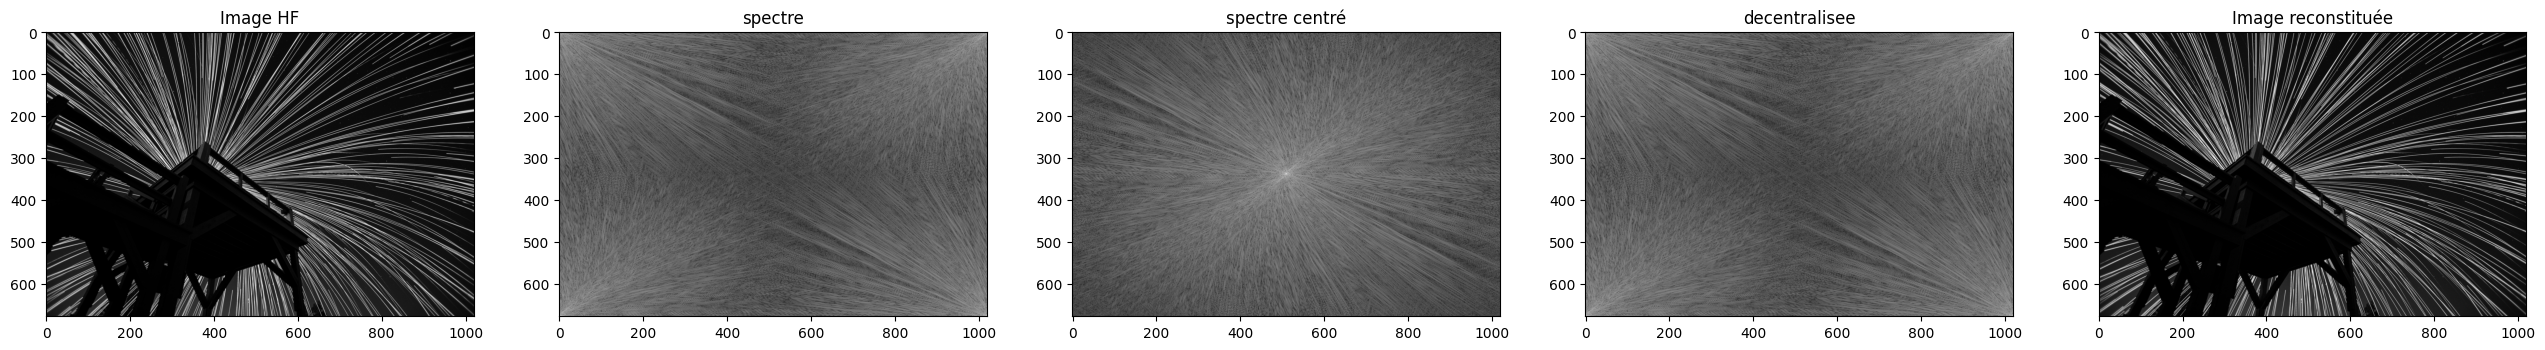

In [ ]:
# Pour effectuer la FFT avec OpenCV, l'image d'entrée doit être convertie en float32 !!
# dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

#Image de haute fréquence
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img_c1 = imread('images/week4_1.png', as_gray=True)

'''
img_c1 : Image d'entrée, contenant à la fois des hautes et basses fréquences.
img_c2 : Application de la transformée de Fourier 2D pour convertir l'image en domaine fréquentiel.
img_c3 : Application de fftshift pour centrer les basses fréquences et faciliter leur visualisation.
img_c4 : Application de ifftshift pour remettre les basses fréquences aux coins de l'image, prêtes pour la transformée inverse.
img_c5 : Application de la transformée de Fourier inverse pour reconstruire l'image à partir des fréquences, ce qui devrait donner une version similaire à l'image d'entrée.
'''
img_c2 = fft2(img_c1)
img_c3 = fftshift(img_c2)
img_c4 = ifftshift(img_c3)
img_c5 = ifft2(img_c4)
# Afficher les images
plt.subplot(1, 5, 1)
plt.imshow(img_c1, cmap='gray')
plt.title('Image HF')
plt.subplot(1, 5, 2)
plt.imshow(np.log(np.abs(img_c2) + 1), cmap='gray')
plt.title('spectre')
plt.subplot(1, 5, 3)
plt.imshow(np.log(np.abs(img_c3) + 1), cmap='gray')
plt.title('spectre centré')
plt.subplot(1, 5, 4)
plt.imshow(np.log(np.abs(img_c4) + 1), cmap='gray')
plt.title('decentralisee')
plt.subplot(1, 5, 5)
plt.imshow(np.abs(img_c5), cmap='gray')
plt.title('Image reconstituée')


plt.show()



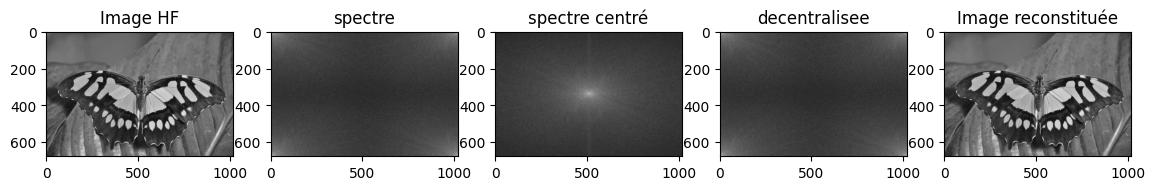

In [59]:
img_c1 = imread('images/week4_2.png', as_gray=True)
# A compléter comme l'image précédente
img_c2 = fft2(img_c1)
img_c3 = fftshift(img_c2)
img_c4 = ifftshift(img_c3)
img_c5 = ifft2(img_c4)
# Afficher les images
plt.figure(figsize=(14, 7))
plt.subplot(1, 5, 1)
plt.imshow(img_c1, cmap='gray')
plt.title('Image HF')
plt.subplot(1, 5, 2)
plt.imshow(np.log(np.abs(img_c2) + 1), cmap='gray')
plt.title('spectre')
plt.subplot(1, 5, 3)
plt.imshow(np.log(np.abs(img_c3) + 1), cmap='gray')
plt.title('spectre centré')
plt.subplot(1, 5, 4)
plt.imshow(np.log(np.abs(img_c4) + 1), cmap='gray')
plt.title('decentralisee')
plt.subplot(1, 5, 5)
plt.imshow(np.abs(img_c5), cmap='gray')
plt.title('Image reconstituée')


plt.show()

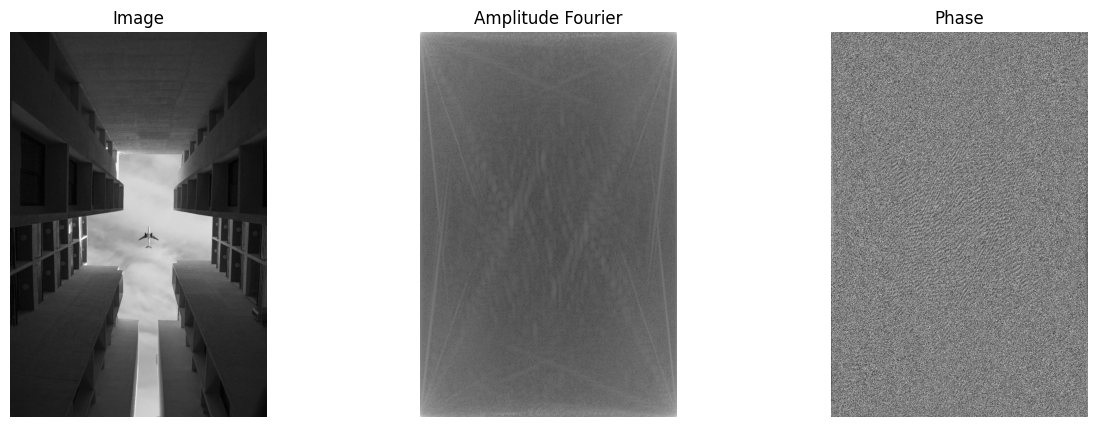

In [11]:
# Lecture de l'image
im = imread('images/airplane.jpg')

# Application de la transformation de Fourier 2D sur l'image 'im'
f = fft2(im)

# Calcul de l'amplitude du spectre de Fourier (magnitude) à partir de 'f'
a = np.abs(f)

# Calcul de la phase du spectre de Fourier à partir de 'f'
p = np.angle(f)


# Affichage de l'image, de son amplitude et da sa phase
# Amplitude: appliquer Logarithme de l'amplitude pour mieux visualiser les fréquences


plt.figure(figsize=(15, 5))
# A compléter ...
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray')
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.log(a + 1e-10), cmap='gray')
plt.title("Amplitude Fourier")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(p, cmap='gray')
plt.title("Phase")
plt.axis("off")

plt.show()

#### Masque de filtrage

##### 1. Filtre Passe-Haut Circulaire

Un **filtre passe-haut** bloque les basses fréquences au centre et laisse passer les hautes fréquences. Ce type de filtre est souvent utilisé pour la **détection de contours** car il permet de renforcer les détails fins, tels que les bords d'une image, et d'amplifier le bruit.

**Propriétés** :

- **Basses fréquences** (qui représentent les informations générales et lissées de l'image) sont bloquées.
- **Hautes fréquences** (qui représentent les détails fins, les textures et les contours) sont laissées passer.
- Ce type de filtre est utile lorsque vous souhaitez **extraire des bords** ou des **détails fins** d'une image.

**Masque** :

- La valeur du masque est de **1** pour les hautes fréquences (zones extérieures du masque) et de **0** pour les basses fréquences (centre du masque).

**Exemple d'application** : 
- Ce type de filtre peut être utilisé pour **accentuer les contours** d'une image ou pour observer les détails fins tout en supprimant l'effet de lissage global.

---

##### 2. Filtre Passe-Bas Circulaire

Un **filtre passe-bas** laisse passer uniquement les basses fréquences et bloque les hautes fréquences. Ce type de filtre est couramment utilisé pour **lisser l'image**, **réduire le bruit** ou **conserver les régions lisses** de l'image tout en éliminant les détails fins et les textures.

**Propriétés** :

- **Basses fréquences** (qui captent l'information générale et lissée) sont laissées passer.
- **Hautes fréquences** (qui contiennent des détails fins et du bruit) sont bloquées.
- Il est souvent utilisé pour **flouter les détails fins** ou pour **réduire le bruit**.

**Masque** :

- La valeur du masque est de **1** pour les basses fréquences (centre du masque) et de **0** pour les hautes fréquences (zones extérieures).

**Exemple d'application** : 
- Ce filtre peut être utilisé pour **adoucir** une image ou pour **réduire le bruit**, mais il peut également **flouter les bords** et les **détails fins**.

---

##### 3. Filtre Passe-Bande Circulaire

Le **filtre passe-bande** est une combinaison des deux filtres précédents : il laisse passer les fréquences dans une certaine **plage de fréquences** et bloque les fréquences plus faibles et plus élevées. Ce type de filtre est utile pour **conserver certaines informations spécifiques** tout en supprimant d'autres fréquences.

**Propriétés** :

- **Laisse passer** les fréquences situées entre deux rayons spécifiés.
- **Bloque** les basses fréquences (en-deçà du rayon minimum) et les hautes fréquences (au-delà du rayon maximum).
- Utilisé pour des applications où vous souhaitez **conserver certains détails intermédiaires** tout en supprimant les effets de bruit et de lissage.

**Masque** :

- Le masque est défini pour être **1** dans la plage de fréquences spécifiques et **0** à l'extérieur de cette plage.
- Ce masque permet de créer une **bande de fréquences passantes** (la zone entre `r_min` et `r_max`).

---

### Applications typiques :

- **Filtre Passe-Haut** : Améliorer les bords et détails fins (exemple : détection de contours).
- **Filtre Passe-Bas** : Lissage de l'image, réduction du bruit.
- **Filtre Passe-Bande** : Conserver des détails spécifiques tout en éliminant le bruit et les fréquences indésirables.



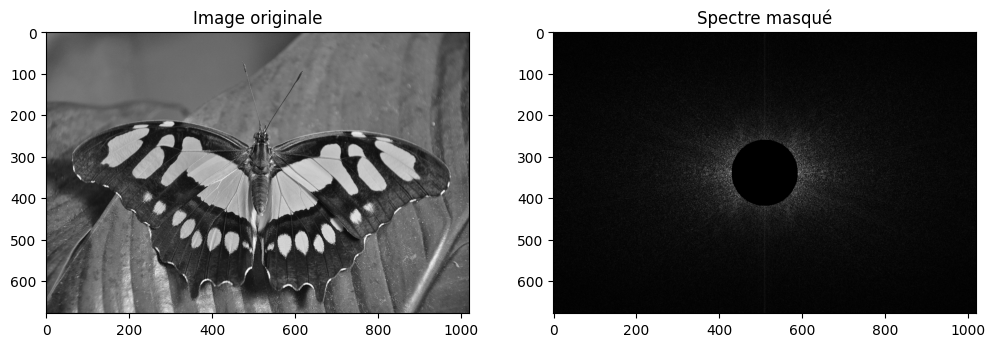

In [17]:
# Charger l'image en niveaux de gris
img = imread('images/week4_2.png', as_gray=True)

# Appliquer la transformée de Fourier 2D avec `numpy`
dft = fft2(img)
dft_shift = fftshift(dft)

# Calcul de la magnitude du spectre
magnitude = np.abs(dft_shift)

# Création d'un masque passe-haut circulaire
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2  # Coordonnées du centre
r = 80  # Rayon du cercle pour bloquer les basses fréquences

# Création du masque
mask = np.ones((rows, cols), dtype=np.float32)

X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
mask_area = (X - ccol)**2 + (Y - crow)**2 <= r**2
mask[mask_area] = 0  # Zéro à l'intérieur du cercle pour bloquer les basses fréquences

# Appliquer le masque au spectre décalé
fshift = dft_shift * mask

# Calcul de la magnitude après application du masque
magnitude_masked = np.abs(fshift)

# Transformée inverse pour reconstruire l'image
img_reconstructed = np.real(ifft2(fshift))



# Affichage des résultats
fig = plt.figure(figsize=(12, 12))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Image originale")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_masked, cmap='gray')
plt.title("Spectre masqué")


plt.show()

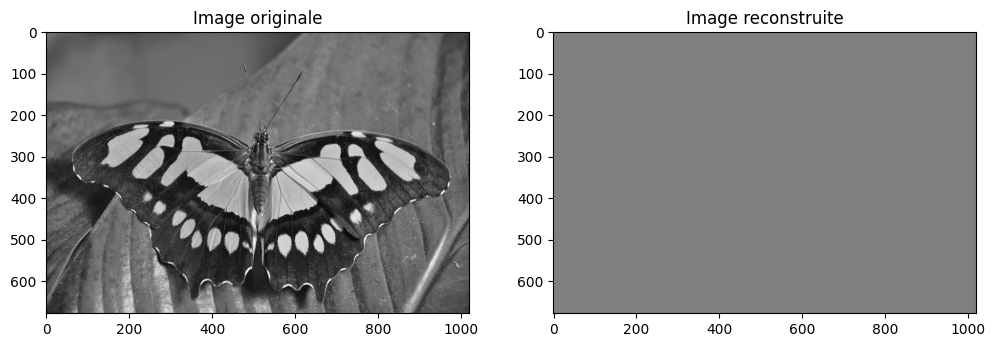

In [18]:

from skimage.io import imread
from skimage.color import rgb2gray
from skimage import img_as_float
import numpy as np
import matplotlib.pyplot as plt

# Charger l'image en niveaux de gris
img = imread('images/week4_2.png', as_gray=True)

# Appliquer la transformée de Fourier 2D avec `numpy`
dft = fft2(img)
# Calcul de la magnitude du spectre
magnitude = np.abs(dft)

# Création d'un masque passe-bande circulaire
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2 

# Rayon pour la fréquence basse et haute
r_min = 30  # Rayon minimum pour le passe-bande
r_max = 80  # Rayon maximum pour le passe-bande

# Création du masque
mask = np.zeros((rows, cols), dtype=np.float32)
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
dist_from_center = np.sqrt((X - ccol)**2 + (Y - crow)**2)
mask_area = (dist_from_center >= r_min) & (dist_from_center <= r_max)
# Remplir le masque pour le passe-bande : entre r_min et r_max
mask_area = (dist_from_center >= r_min) & (dist_from_center <= r_max)
mask[mask_area] = 1  # 1 dans la bande sélectionnée

# Appliquer le masque au spectre décalé
dft_shift = fftshift(dft)
fshift = dft_shift * mask
# Calcul de la magnitude après application du masque
magnitude_masked = np.abs(fshift)

# Transformée inverse pour reconstruire l'image
img_reconstructed = np.real(ifft2(fshift))

# Affichage des résultats
fig = plt.figure(figsize=(12, 12))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Image originale")

plt.subplot(1, 2, 2)
plt.imshow(img_reconstructed, cmap='gray')
plt.title("Image reconstruite")

plt.show()

#### Remarque :
- **Filtre Passe Bas:** 
  Le filtre PB applique un poids gaussien centré sur les basses fréquences (fréquences proches du centre de l'image transformée). Cela préserve les fréquences basses tout en atténuant les hautes fréquences.

  $$
  PB(u, v) = e^{-\frac{D(u, v)^2}{2D_0^2}}
 $$

- **Filter Passe-Haut:** 
  Le filtre PH supprime les basses fréquences tout en préservant les hautes fréquences. Il est obtenu en soustrayant un filtre passe-bas d'une constante maximale (1).

  $$
  PH(u, v) = 1 - e^{-\frac{D(u, v)^2}{2D_0^2}}
$$

---

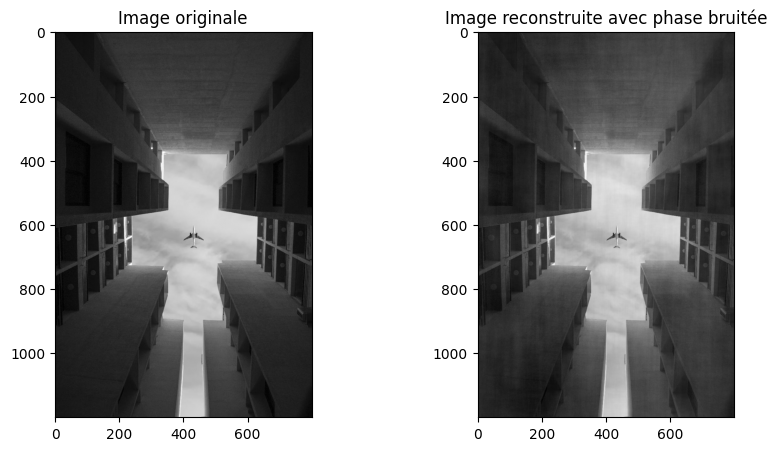

In [19]:
def ampl(f):
    return np.abs(f)

def phase(f):
    return np.angle(f)

def fourier2D(im):
    return fft2(im)

# Fonction de reconstruction de l'image à partir de l'amplitude et de la phase
def reconstruct(ampl, phase):
    # Recréer le spectre complexe en utilisant l'amplitude et la phase
    f = ampl * np.exp(1j * phase)
    # Retourner l'image reconstruite en appliquant la transformation inverse de Fourier 2D
    return np.real(ifft2(f))

# Charger l'image d'entrée
im = imread('images/airplane.jpg')

# Appliquer la transformation de Fourier 2D sur l'image
f = fourier2D(im)

# Calculer l'amplitude et la phase du spectre
a = ampl(f)
p = phase(f)

# Reconstruction de l'image avec la phase perturbée par un bruit aléatoire
r = reconstruct(a, p + np.random.random((p.shape)) * 2 * np.pi/10)
# Affichage de l'image originale et de l'image reconstruite
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(im, cmap='gray')
plt.title("Image originale")
plt.subplot(1, 2, 2)
plt.imshow(r, cmap='gray')
plt.title("Image reconstruite avec phase bruitée")
plt.show()

#### Visualisation de la reconstruction itérative
---
La reconstruction itérative est un processus où l'on reconstruit progressivement une image ou un signal à partir de ses composantes de fréquence. Cette méthode est particulièrement utilisée en traitement du signal, en imagerie médicale (comme en tomographie) et en informatique graphique. Elle consiste à appliquer des mises à jour successives pour améliorer la qualité de l'image reconstruite.

Dans le contexte de la transformée de Fourier, cela implique généralement la reconstruction d'une image à partir de son amplitude et de sa phase par itérations successives. Ce processus permet de récupérer des détails fins et d'ajuster progressivement l'image pour qu'elle corresponde de plus en plus à l'image d'origine.

## Fonctionnement :
1. **Initialisation** : On commence avec une estimation approximative de l'image.
2. **Itérations** : À chaque étape, l'image est mise à jour en utilisant les informations de fréquence (amplitude et phase) et en appliquant des transformations inverses de Fourier.
3. **Convergence** : Les itérations continuent jusqu'à ce que l'image reconstruite atteigne un critère de convergence ou qu'un nombre d'itérations soit atteint.

Ce processus peut être visualisé à chaque étape, montrant comment l'image se rapproche de la version finale au fur et à mesure que les itérations avancent.



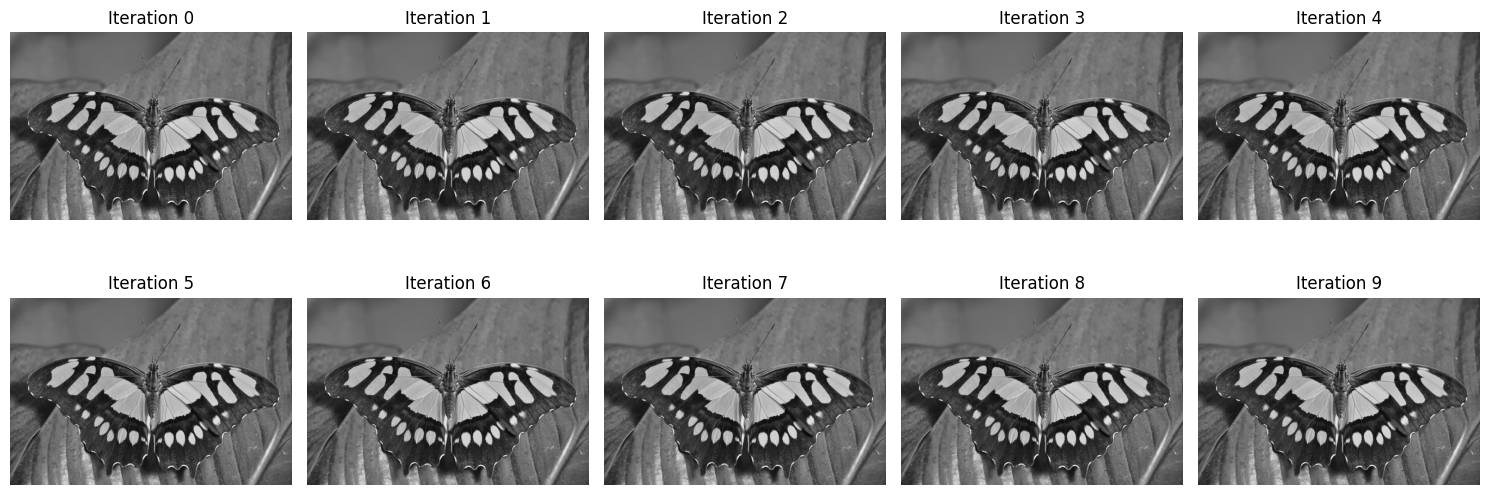

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage import img_as_float

# Charger l'image en niveaux de gris
img = imread('images/week4_2.png', as_gray=True)

# Appliquer la transformée de Fourier 2D
tfd = fourier2D(img)  # FFT
magnitude = ampl(tfd) # Magnitude (amplitude)
phase = phase(tfd)  # Phase

# Reconstruction itérative
n_iterations = 10
reconstructed_images = []



# Initialisation : démarrer avec l'image d'origine
reconstructed = img

for i in range(n_iterations+1):
    # Calculer la FFT de l'image reconstruite
    reconstructed_dft = fourier2D(reconstructed)
    
    # Imposer la magnitude de l'originale et garder la phase actuelle
    new_dft = magnitude * np.exp(1j * np.angle(reconstructed_dft))
    
    # Calcul de la transformation inverse
    reconstructed = np.real(ifft2(new_dft))
    
    # Normalisation de l'image reconstruite pour s'assurer qu'elle reste dans l'échelle [0, 1]
    reconstructed = (reconstructed - reconstructed.min()) / (reconstructed.max() - reconstructed.min())
    
    # Sauvegarder l'image reconstruite pour visualisation
    reconstructed_images.append(reconstructed)
    
   

# Affichage des résultats
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(reconstructed_images[i], cmap='gray')
    ax.set_title(f"Iteration {i}")
    ax.axis('off')
plt.tight_layout()
plt.show()

<div style="color:blue"> 

***
# Fin du TP2
***
    
</div>